In [158]:
import numpy as np
import pandas as pd

In [159]:
df=pd.read_csv("insurance.csv")

In [160]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [161]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [162]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [164]:
df["sex"] = df["sex"].map({"male": 1, "female": 0})
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})
df["smoker_bmi"]=df["smoker"]*df["bmi"]
df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_bmi
0,19,0,27.900,0,1,southwest,16884.92400,27.9
1,18,1,33.770,1,0,southeast,1725.55230,0.0
2,28,1,33.000,3,0,southeast,4449.46200,0.0
3,33,1,22.705,0,0,northwest,21984.47061,0.0
4,32,1,28.880,0,0,northwest,3866.85520,0.0


In [165]:
x_train=df[["age","bmi","children","sex","smoker","smoker_bmi"]].to_numpy()
y_train=df["charges"].to_numpy()

In [166]:
import matplotlib.pyplot as plt

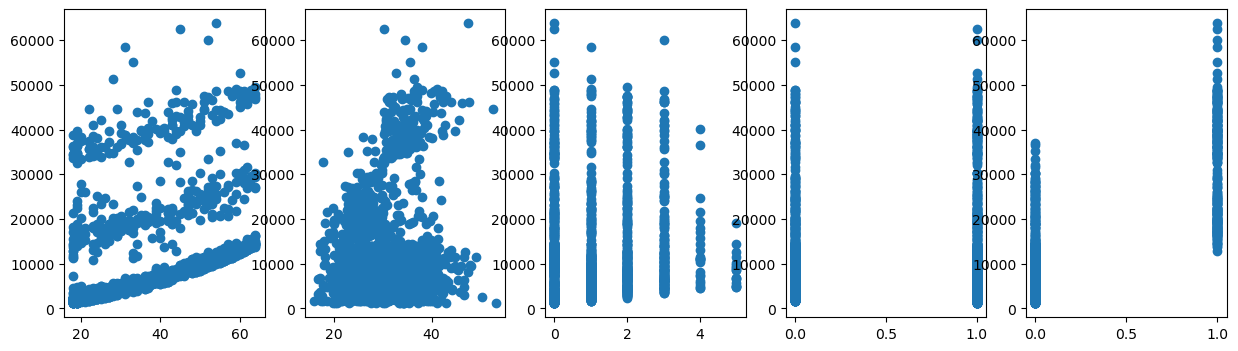

In [167]:
fig,ax=plt.subplots(1,5,figsize=(15,4))
for i in range(0,5):
    ax[i].scatter(x_train[:,i],y_train)
plt.show()

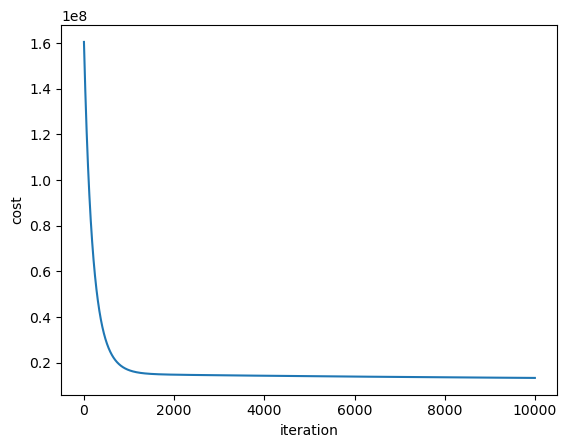

w: [3670.0135224   995.96565611  593.44757183 -171.14027325  653.02166271
 9388.43801224] b: 13270.453851390563


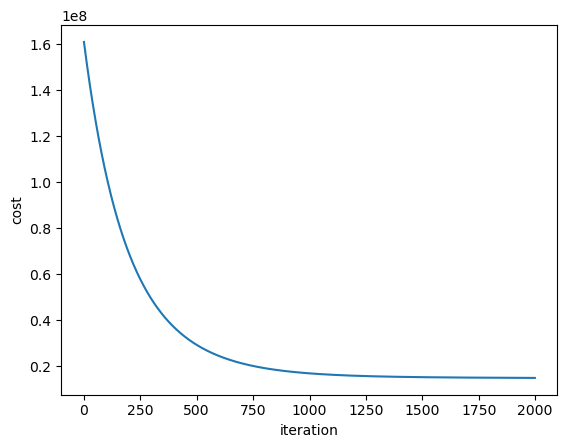

train cost: 14982973.724374434
test  cost: 13823678.97247456


In [186]:
def zscore(x):
    sigma= x.std(axis=0)
    mu = x.mean(axis=0)
    return (x-mu)/sigma,mu,sigma

def cost(x,y,w,b):
    f=0
    m=len(y)
    for i in range(0,m):
        f+=(np.dot(x[i],w)+b-y[i])**2
    costed=f/(2*m)
    return costed 


def show(costs):
    plt.plot(costs)
    plt.xlabel("iteration")
    plt.ylabel("cost")
    plt.show()

def gradientdecent(x,y,a,iteration,w,b):
    n=x.shape[1]
    m=x.shape[0]
    x_forshow=[]
    y_forshow=[]
    for it in range (iteration):
        for j in range(0,m):
            f=np.dot(x[j],w)+b-y[j]
            for i in range(n):
                w[i]=w[i]-((a/m)*f)*x[j][i]
            b=b-((a/m)*f)
        costed=cost(x,y,w,b)
        x_forshow.append(costed)
    show(x_forshow)
    return w,b

x_norm,mu,sigma=zscore(x_train)
a=2e-3
w=np.zeros(x_train.shape[1])
b=0
iteration=10000 
w,b=gradientdecent(x_norm,y_train,a,iteration,w,b)
print("w:",w,"b:",b)
n = len(y_train)

idx = np.random.permutation(n)     # shuffle row positions
split = int(0.8 * n)

X_tr, X_te = x_norm[idx[:split]], x_norm[idx[split:]]
y_tr, y_te = y_train[idx[:split]], y_train[idx[split:]]

w, b = gradientdecent(X_tr, y_tr, 2e-3, 2000, np.zeros(6), 0)

print("train cost:", cost(X_tr, y_tr, w, b))
print("test  cost:", cost(X_te, y_te, w, b))



In [187]:
person = np.array([35, 1, 28.5, 2, 1, 28.5])
person_norm = (person - mu) / sigma
prediction = np.dot(w, person_norm) + b
print(prediction)

34036.94493298182


In [188]:
print("mu:", mu)
print("sigma:", sigma)

mu: [39.20702541 30.66339686  1.09491779  0.50523169  0.20478326  6.28857623]
sigma: [14.04470904  6.09590764  1.20504217  0.49997263  0.40354315 12.7166197 ]


In [189]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_tr, y_tr)
print("sklearn w:", model.coef_)
print("sklearn b:", model.intercept_)
print("sklearn test cost:", cost(X_te, y_te, model.coef_, model.intercept_))

sklearn w: [ 3696.57904786   -36.31109581   512.9124718   -142.59331058
 -8489.04207099 18557.24291799]
sklearn b: 13338.25729550836
sklearn test cost: 11390606.335555186
